# Notebook 3: Plot vertical atmospheric profiles 

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib
plt.rcParams['figure.figsize'] = [10,10]
plt.rcParams.update({'font.size': 20})
import xarray as xr 
import warnings
import seaborn as sns

import matplotlib.lines as mlines

warnings.filterwarnings("ignore")
import glob as glob

In [2]:
#Sounding specific functions
from metpy.plots import SkewT
from metpy.units import pandas_dataframe_to_unit_arrays, units
from metpy.calc import  mixed_layer_cape_cin, most_unstable_cape_cin, cape_cin, surface_based_cape_cin
from metpy.calc import parcel_profile


In [3]:
out_dir = "./plots/"

## Some functions

In [4]:
def calc_vapor_pressure(qv, p):
    return qv * p / (0.622 + qv)


def calc_dew_point(e):
    return 243.12 * np.log(e / 6.112) / (17.62 - np.log(e / 6.112))

In [5]:
def find_nearest_index(ds, target_lat, target_lon):
    lon = np.rad2deg(ds.clon)
    lat = np.rad2deg(ds.clat)

    distance = np.sqrt((lon - target_lon) ** 2 + (lat - target_lat) ** 2)
    return np.argmin(distance.values)

In [6]:
def extract_profile_vars(ds_trc, ds_cld, ds_dyn, time, index):
    p = (ds_trc["pfull"] / 100).sel(time=time).isel(ncells=index)
    T = (ds_trc["ta"] - 273.15).sel(time=time).isel(ncells=index)
    qv = ds_cld["hus"].sel(time=time).isel(ncells=index)
    u = ds_dyn["ua"].sel(time=time).isel(ncells=index)
    v = ds_dyn["va"].sel(time=time).isel(ncells=index)

    return p, T, qv, u, v

In [7]:
def compute_cape_metrics(p, T, qv):
    vapor_pressure = calc_vapor_pressure(qv, p)
    dew_point = calc_dew_point(vapor_pressure)

    Td = xr.DataArray(
        dew_point,
        dims=qv.dims,
        coords=qv.coords,
        name="Dew_Point"
    )

    p_c = (p.values * units.hPa)[::-1]
    T_c = (T.values * units.degC)[::-1]
    Td_c = (Td.values * units.degC)[::-1]

    cape, cin = surface_based_cape_cin(p_c, T_c, Td_c)
    cape_mu, cin_mu = most_unstable_cape_cin(p_c, T_c, Td_c)

    return cape, cin, cape_mu, cin_mu, p_c, T_c, Td_c, Td

## Get and prepare data

In [8]:
h = xr.open_dataset( "./data/grids/lam_hra_2025_atm_vgrid_ml.nc" , engine='netcdf4').mean("ncells").zg/1000

In [9]:
# Model data
data_path = "/work/bb1174/user/jason/hra_data/lam_hra_2025_25/"

dyn_files = sorted(glob.glob(data_path + "*/*dyn*.nc"))
cld_files = sorted(glob.glob(data_path + "*/*cld*.nc"))
trc_files = sorted(glob.glob(data_path + "*/*trc*Z.nc"))

ds_dyn = xr.open_mfdataset(dyn_files, engine="netcdf4")
ds_cld = xr.open_mfdataset(cld_files, engine="netcdf4")
ds_trc = xr.open_mfdataset(trc_files, engine="netcdf4")

In [10]:
# Model grid
lon = np.rad2deg(ds_trc.clon)
lat = np.rad2deg(ds_trc.clat)

# Evaluation locations
lat_station, lon_station = [60.026], [-111.929]
lat_fire, lon_fire = [56.9], [-113.8]

In [11]:
# Nearest grid cells
station_index = find_nearest_index(ds_trc, lat_station, lon_station)
fire_index = find_nearest_index(ds_trc, lat_fire, lon_fire)

In [12]:
# Analysis times
time_start = "2025-05-30T00:00:00"
time_pyrocb = "2025-05-30T01:30:00"

In [13]:
p_station, T_station, qv_station, u_station, v_station = extract_profile_vars(
    ds_trc, ds_cld, ds_dyn,
    time_start,
    station_index
)

In [14]:
p_fire, T_fire, qv_fire, u_fire, v_fire = extract_profile_vars(
    ds_trc, ds_cld, ds_dyn,
    time_pyrocb,
    fire_index
)

## Observations

In [15]:
# Observed sounding
data = np.loadtxt("./data/obs/obs.txt")

obsP = data[:, 0]   # Pressure
obsT = data[:, 2]   # Temperature
obsDT = data[:, 3]  # Dew point

## Compute Cape Values

In [16]:
def compute_cape_metrics(p, T, qv):
    vapor_pressure = calc_vapor_pressure(qv, p)
    dew_point = calc_dew_point(vapor_pressure)

    Td = xr.DataArray(
        dew_point,
        dims=qv.dims,
        coords=qv.coords,
        name="Dew_Point"
    )

    p_c  = (p.values * units.hPa)[::-1]
    T_c  = (T.values * units.degC)[::-1]
    Td_c = (Td.values * units.degC)[::-1]

    cape, cin = surface_based_cape_cin(p_c, T_c, Td_c)
    cape_mu, cin_mu = most_unstable_cape_cin(p_c, T_c, Td_c)

    return cape, cin, cape_mu, cin_mu, p_c, T_c, Td_c, Td

In [17]:
cape_station, cin_station, cape_mu_station, cin_mu_station, p_c_station, T_c_station, Td_c_station, Td_station = (
    compute_cape_metrics(p_station, T_station, qv_station)
)

cape_fire, cin_fire, cape_mu_fire, cin_mu_fire, p_c_fire, T_c_fire, Td_c_fire, Td_fire = (
    compute_cape_metrics(p_fire, T_fire, qv_fire)
)

## Plot Figure

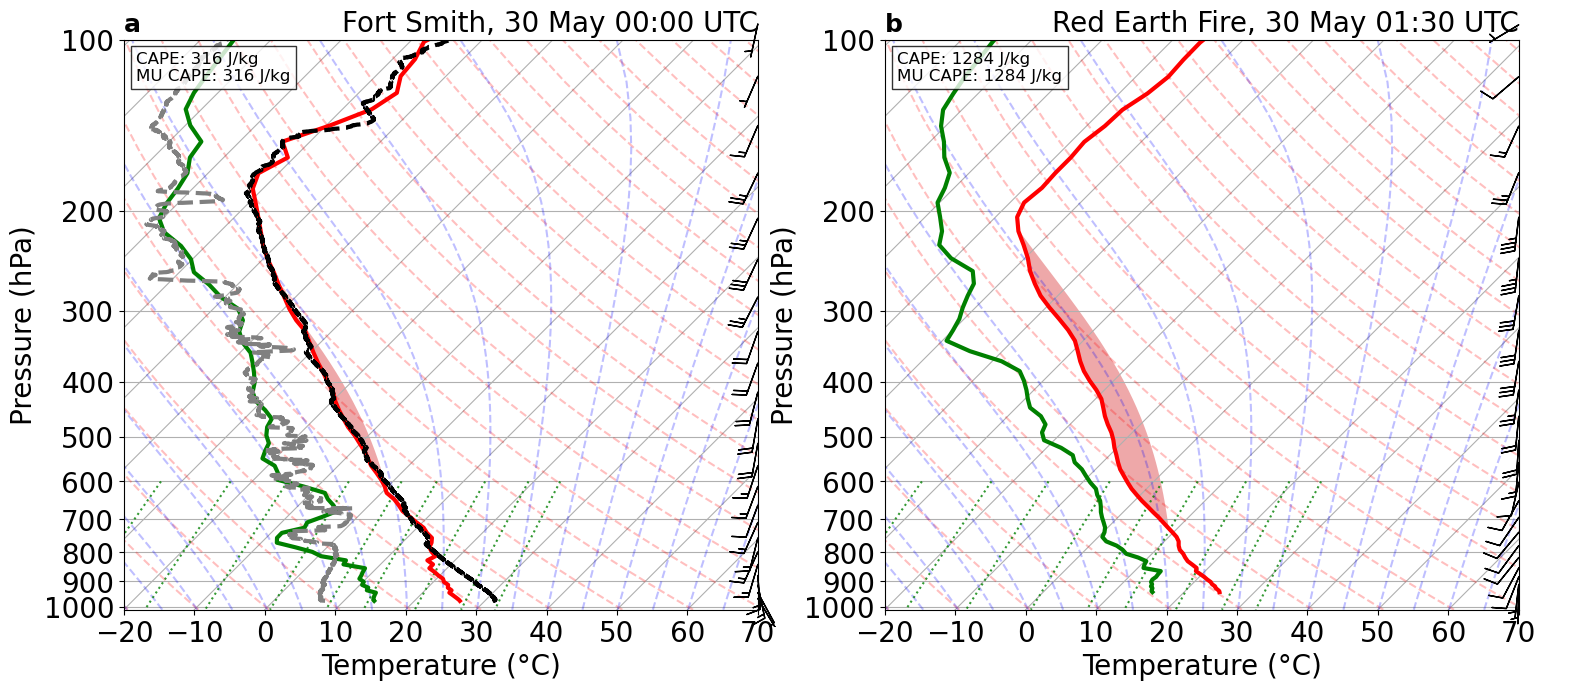

In [18]:
def make_skewt_panel(
    fig, subplot, p, T, Td, u, v,
    p_c, T_c, parcel_prof,
    cape, cape_mu, title, panel_label,
    add_obs=False
):
    skew = SkewT(fig, rotation=45, subplot=subplot)

    # Model sounding
    skew.plot(p, T, "r", linewidth=3, label="Temperature")
    skew.plot(p, Td, "g", linewidth=3, label="Dew point")
    skew.plot_barbs(p[::3], u[::3], v[::3], y_clip_radius=0.03)

    # Observed sounding
    if add_obs:
        skew.plot(
            obsP, obsT, "k--", linewidth=3,
            label="Observed temperature"
        )
        skew.plot(
            obsP, obsDT, color="gray", linestyle="--", linewidth=3,
            label="Observed dew point"
        )

    skew.ax.set_xlim(-20, 70)
    skew.ax.set_ylim(1010, 100)

    # Axis labels
    skew.ax.set_xlabel("Temperature (°C)", fontsize=20)
    skew.ax.set_ylabel("Pressure (hPa)", fontsize=20)

    skew.plot_dry_adiabats(
        t0=np.arange(233, 533, 10) * units.K,
        alpha=0.25, color="orangered"
    )
    skew.plot_moist_adiabats(
        t0=np.arange(233, 400, 5) * units.K,
        alpha=0.25, color="tab:green"
    )
    skew.plot_mixing_lines(
        linestyle="dotted", color="tab:blue"
    )

    skew.shade_cape(p_c, T_c, parcel_prof)

    text = (
        f"CAPE: {cape.to('J/kg').m:.0f} J/kg\n"
        f"MU CAPE: {cape_mu.to('J/kg').m:.0f} J/kg"
    )

    skew.ax.text(
        0.02, 0.98, text,
        transform=skew.ax.transAxes,
        fontsize=12,
        va="top",
        bbox=dict(facecolor="white", alpha=0.8)
    )

    skew.ax.set_title(
        panel_label, loc="left",
        fontweight="bold", fontsize=18
    )
    skew.ax.set_title(
        title, loc="right", fontsize=20
    )

    return skew


# Parcel profiles
parcel_prof_station = parcel_profile(
    p_c_station, T_c_station[0], Td_c_station[0]
).to("degC")

parcel_prof_fire = parcel_profile(
    p_c_fire, T_c_fire[0], Td_c_fire[0]
).to("degC")


# Figure
fig = plt.figure(figsize=(18, 12))

skew_station = make_skewt_panel(
    fig, (1, 2, 1),
    p_station, T_station, Td_station, u_station, v_station,
    p_c_station, T_c_station, parcel_prof_station,
    cape_station, cape_mu_station,
    title="Fort Smith, 30 May 00:00 UTC",
    panel_label="a",
    add_obs=True
)

skew_fire = make_skewt_panel(
    fig, (1, 2, 2),
    p_fire, T_fire, Td_fire, u_fire, v_fire,
    p_c_fire, T_c_fire, parcel_prof_fire,
    cape_fire, cape_mu_fire,
    title="Red Earth Fire, 30 May 01:30 UTC",
    panel_label="b"
)

plt.show()

fig.savefig(
    out_dir + "radio_sounding.png",
    dpi=300,
    bbox_inches="tight"
)